In [2]:

## Importing important Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## ------------------------------------
# Loading and Data Cleaning
## ----------------------------------------

In [3]:
df1 = pd.read_csv('List_of_Orders.csv')
df1

,Order ID,Order Date,CustomerName,State,City
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad
1,B-25602,01-04-2018,Pearl,Maharashtra,Pune
2,B-25603,03-04-2018,Jahan,Madhya Pradesh,Bhopal
3,B-25604,03-04-2018,Divsha,Rajasthan,Jaipur
4,B-25605,05-04-2018,Kasheen,West Bengal,Kolkata
...,...,...,...,...,...
555,NaN,NaN,NaN,NaN,NaN
556,NaN,NaN,NaN,NaN,NaN
557,NaN,NaN,NaN,NaN,NaN
558,NaN,NaN,NaN,NaN,NaN


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 22.0+ KB


In [5]:
df1.isnull().mean()

Order ID        0.107143
Order Date      0.107143
CustomerName    0.107143
State           0.107143
City            0.107143
dtype: float64

In [6]:
df1.dropna(how= 'all', inplace= True)


In [7]:
df1.isnull().mean()

Order ID        0.0
Order Date      0.0
CustomerName    0.0
State           0.0
City            0.0
dtype: float64

In [8]:
df1.duplicated().value_counts()

False    500
Name: count, dtype: int64

In [9]:
df1['Order Date']= pd.to_datetime(df1['Order Date'], errors= 'coerce')

In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      500 non-null    object        
 1   Order Date    193 non-null    datetime64[ns]
 2   CustomerName  500 non-null    object        
 3   State         500 non-null    object        
 4   City          500 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 23.4+ KB


In [11]:
df2 = pd.read_csv('Order_Details.csv')
df2

,Order ID,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,1275.0,-1148.0,7,Furniture,Bookcases
1,B-25601,66.0,-12.0,5,Clothing,Stole
2,B-25601,8.0,-2.0,3,Clothing,Hankerchief
3,B-25601,80.0,-56.0,4,Electronics,Electronic Games
4,B-25602,168.0,-111.0,2,Electronics,Phones
...,...,...,...,...,...,...
1495,B-26099,835.0,267.0,5,Electronics,Phones
1496,B-26099,2366.0,552.0,5,Clothing,Trousers
1497,B-26100,828.0,230.0,2,Furniture,Chairs
1498,B-26100,34.0,10.0,2,Clothing,T-shirt


### Separating a dataframe kf from df2 to have better Profit Analysis where there has been No Loss(Profit<0)

In [12]:
kf = df2[df2['Profit'] >=0]
kf

,Order ID,Amount,Profit,Quantity,Category,Sub-Category
6,B-25602,2617.0,1151.0,4,Electronics,Phones
7,B-25602,561.0,212.0,3,Clothing,Saree
12,B-25603,180.0,5.0,3,Clothing,Trousers
13,B-25603,116.0,16.0,4,Clothing,Stole
14,B-25603,107.0,36.0,6,Clothing,Stole
...,...,...,...,...,...,...
1495,B-26099,835.0,267.0,5,Electronics,Phones
1496,B-26099,2366.0,552.0,5,Clothing,Trousers
1497,B-26100,828.0,230.0,2,Furniture,Chairs
1498,B-26100,34.0,10.0,2,Clothing,T-shirt


In [13]:
kf.describe()

,Amount,Profit,Quantity
count,997.000000,997.000000,997.000000
mean,307.233701,68.396189,3.754263
std,496.561674,130.238777,2.181244
min,6.000000,0.000000,1.000000
25%,52.000000,9.000000,2.000000
50%,125.000000,24.000000,3.000000
75%,345.000000,68.000000,5.000000
max,5729.000000,1698.000000,14.000000


### Separating a dataframe tf from df2 to have better Loss Analysis 

In [14]:
tf = df2[df2['Profit'] < 0]
tf.shape

(503, 6)

In [15]:
tf.rename(columns={'Profit': 'Loss'}, inplace=True)
tf.columns

C:\Users\Gaurav\AppData\Local\Temp\ipykernel_23056\2472720794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tf.rename(columns={'Profit': 'Loss'}, inplace=True)


Index(['Order ID', 'Amount', 'Loss', 'Quantity', 'Category', 'Sub-Category'], dtype='object')

In [16]:
tf.describe()

,Amount,Loss,Quantity
count,503.000000,503.000000,503.000000
mean,248.886680,-87.944334,3.721670
std,378.488771,188.399362,2.194267
min,4.000000,-1981.000000,1.000000
25%,34.500000,-78.000000,2.000000
50%,93.000000,-28.000000,3.000000
75%,275.500000,-9.000000,5.000000
max,3151.000000,-1.000000,13.000000


In [17]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      1500 non-null   object 
 1   Amount        1500 non-null   float64
 2   Profit        1500 non-null   float64
 3   Quantity      1500 non-null   int64  
 4   Category      1500 non-null   object 
 5   Sub-Category  1500 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 70.4+ KB


In [18]:
df2.isnull().mean()

Order ID        0.0
Amount          0.0
Profit          0.0
Quantity        0.0
Category        0.0
Sub-Category    0.0
dtype: float64

In [19]:
df2.duplicated().value_counts()

False    1500
Name: count, dtype: int64

In [20]:
df3 = pd.read_csv('Sales_target.csv')
df3.head()

,Month of Order Date,Category,Target
0,Apr-18,Furniture,10400.0
1,May-18,Furniture,10500.0
2,Jun-18,Furniture,10600.0
3,Jul-18,Furniture,10800.0
4,Aug-18,Furniture,10900.0


In [21]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Month of Order Date  36 non-null     object 
 1   Category             36 non-null     object 
 2   Target               36 non-null     float64
dtypes: float64(1), object(2)
memory usage: 992.0+ bytes


In [22]:
df3.isnull().mean()

Month of Order Date    0.0
Category               0.0
Target                 0.0
dtype: float64

In [23]:
df3.duplicated().value_counts()

False    36
Name: count, dtype: int64

In [24]:
M1 = pd.merge(kf, df1, on= 'Order ID', how= 'left')               ## Merging for Profit Analysis where kf is used
M2 = pd.merge(tf, df1, on= 'Order ID', how= 'left')               ## Merging for Loss Analysis where tf is used
M3 = pd.merge(df2, df1, on= 'Order ID', how= 'left')              ## Merging For OverAll Analysis where df2 is used


## Total Sales by Category

In [25]:
category_sales = M3.groupby('Category')['Amount'].sum().reset_index().rename(columns={'Amount': 'Total_Sales'})
category_sales

,Category,Total_Sales
0,Clothing,139054.0
1,Electronics,165267.0
2,Furniture,127181.0


# Exploratary Data Analysis

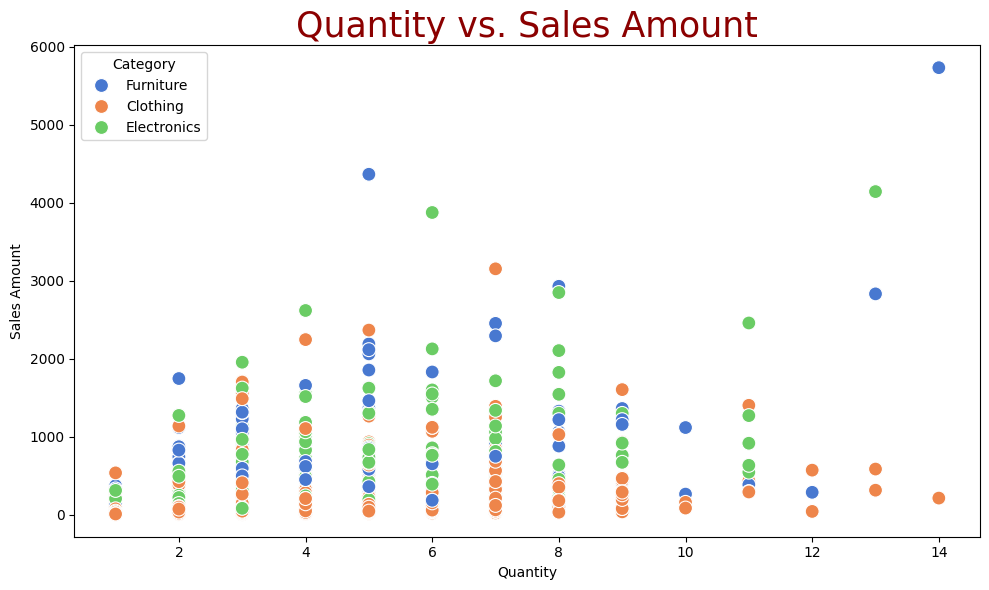

In [26]:
## ---  Quantity vs. Sales Amount ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=M3, x='Quantity', y='Amount', hue='Category',  s=100, palette='muted')
plt.title('Quantity vs. Sales Amount' , fontsize = 25, color = 'darkred')
plt.xlabel('Quantity')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.show()

## We can Infer from the above  Chart that as the Quantities Increases Sales also Inceases; In the mid Section( Where Quantity = 5 - 10) Maximum Sales has been Witnessed 
## When Quantities is High(in case of Clothing), Sales Amount Decreases , vice - versa is also TRUE here.

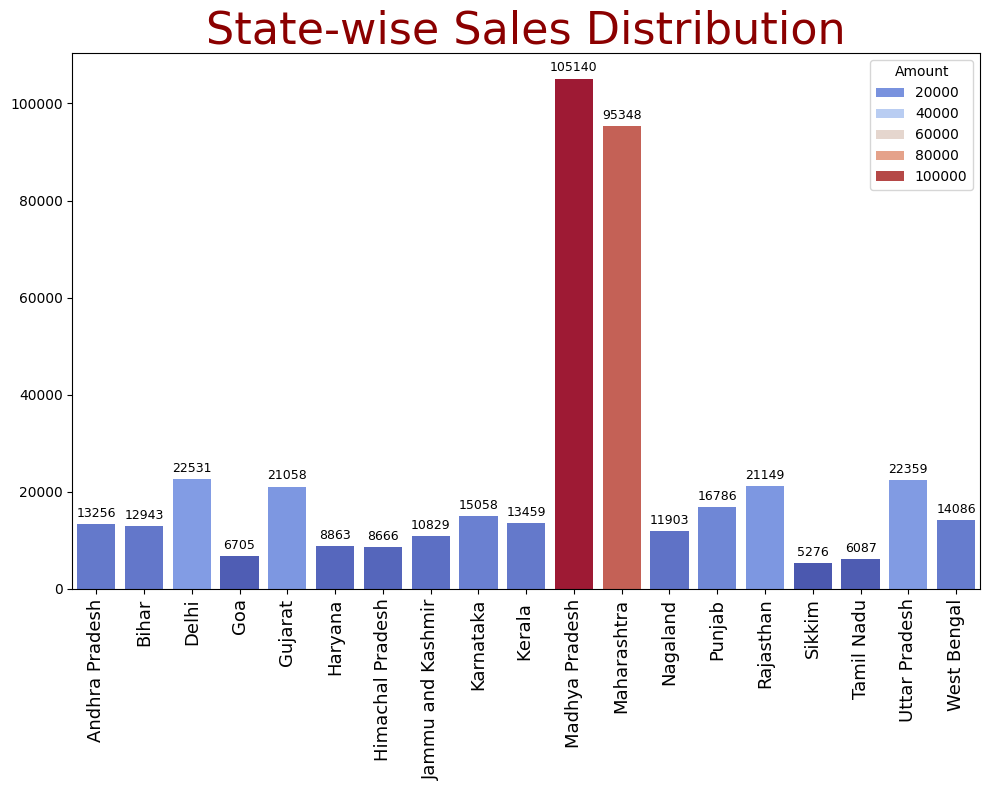

In [27]:
## State-wise Sales Distribution 


plt.figure(figsize=(10, 8))
sales_by_state = M3.groupby('State')['Amount'].sum().reset_index()
fx = sns.barplot(data=sales_by_state, x='State', y='Amount', palette='coolwarm', hue = 'Amount')


for p in fx.patches:
    height = p.get_height()
    if height > 0:
        fx.annotate(f'{height:.0f}', 
            xy=(p.get_x() + p.get_width() / 2, height), 
            xytext=(0, 3), 
            textcoords="offset points",
            ha='center', va='bottom', fontsize=9, rotation=0)
        


plt.title('State-wise Sales Distribution', fontsize = 32, color = 'darkred')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=90, fontsize = 13)
plt.tight_layout()
plt.show()





## MP & Maharashtra Witnesses Highest Total Sales in all Categories

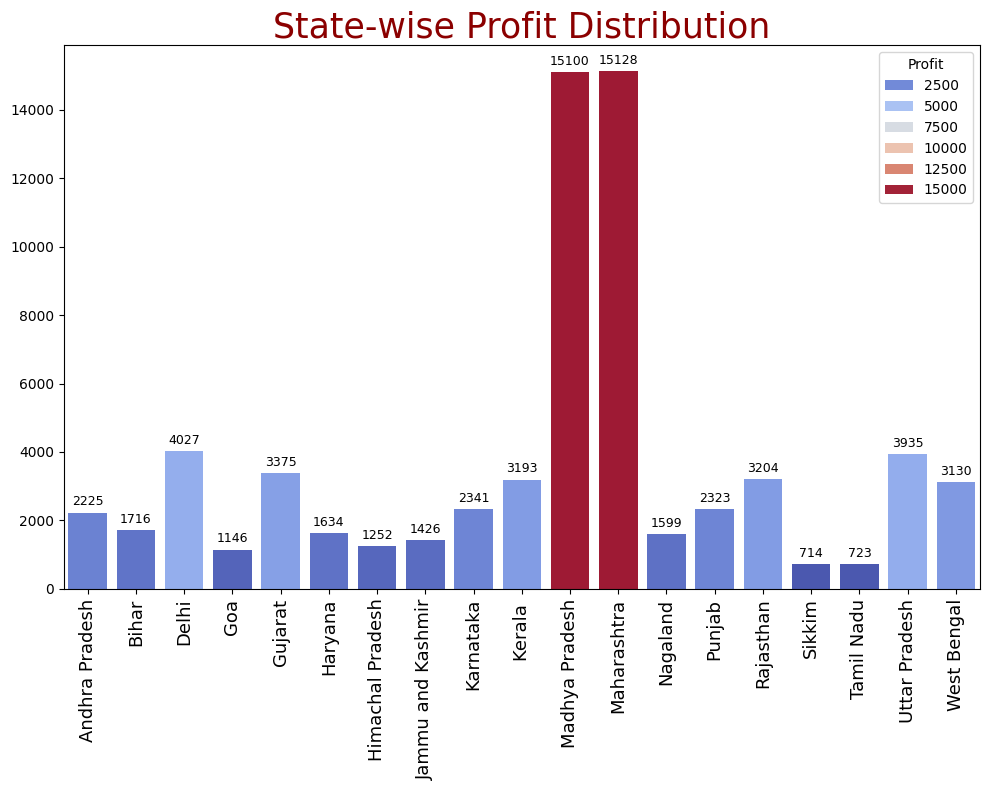

In [28]:
plt.figure(figsize=(10, 8))
Loss_sales_by_state = M1.groupby('State')['Profit'].sum().reset_index()
yx = sns.barplot(data=Loss_sales_by_state, x='State', y='Profit', palette='coolwarm', hue = 'Profit')


for p in yx.patches:
    height = p.get_height()
    if height > 0:
        yx.annotate(f'{height:.0f}', 
            xy=(p.get_x() + p.get_width() / 2, height), 
            xytext=(0, 3),  
            textcoords="offset points",
            ha='center', va='bottom', fontsize=9, rotation=0)
        


plt.title('State-wise Profit Distribution', fontsize = 25, color = 'darkred')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=90, fontsize = 13)
plt.tight_layout()
plt.show()


## MP & Maharashtra Witness Highest Profits (almost same)


# Part 1  Sales Analysis

In [29]:
category_metrics = M3.groupby('Category').agg(
    Total_Profit=('Profit', 'sum'),
    Average_Profit_Per_Order=('Profit', 'mean'),
    Total_Sales=('Amount', 'sum')
).reset_index()

category_metrics['Profit_Margin (%)'] = round((category_metrics['Total_Profit'] / category_metrics['Total_Sales']) * 100, 2)

In [30]:
category_metrics

,Category,Total_Profit,Average_Profit_Per_Order,Total_Sales,Profit_Margin (%)
0,Clothing,11163.0,11.762908,139054.0,8.03
1,Electronics,10494.0,34.071429,165267.0,6.35
2,Furniture,2298.0,9.456790,127181.0,1.81


In [31]:
sorted_metrics = category_metrics.sort_values(by=['Total_Profit', 'Profit_Margin (%)'], ascending=[False, False])
top_performing = sorted_metrics.iloc[0]
underperforming = sorted_metrics.iloc[-1]

## Sorting Categories by Total Profit & Profit Margin


In [32]:
sorted_metrics

,Category,Total_Profit,Average_Profit_Per_Order,Total_Sales,Profit_Margin (%)
0,Clothing,11163.0,11.762908,139054.0,8.03
1,Electronics,10494.0,34.071429,165267.0,6.35
2,Furniture,2298.0,9.456790,127181.0,1.81


In [33]:
top_performing

Category                     Clothing
Total_Profit                  11163.0
Average_Profit_Per_Order    11.762908
Total_Sales                  139054.0
Profit_Margin (%)                8.03
Name: 0, dtype: object

In [34]:
underperforming

Category                    Furniture
Total_Profit                   2298.0
Average_Profit_Per_Order      9.45679
Total_Sales                  127181.0
Profit_Margin (%)                1.81
Name: 2, dtype: object

## Top Performing Product Category: Clothing
## Under Performing Product Category : Furniture

In [35]:
## Top  Clothing Products by Total Sales

clothing_sales_top10 = (
    df2[df2['Category'] == 'Clothing']
    .groupby('Sub-Category')['Amount']
    .sum()
    .sort_values(ascending=False).head(10)
    
)

clothing_sales_top10

Sub-Category
Saree          53511.0
Trousers       30039.0
Stole          18546.0
Hankerchief    14608.0
Shirt           7555.0
T-shirt         7382.0
Kurti           3361.0
Leggings        2106.0
Skirt           1946.0
Name: Amount, dtype: float64

C:\Users\Gaurav\AppData\Local\Temp\ipykernel_23056\196722235.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clothing_sales_top10.values, y=clothing_sales_top10.index, palette='Blues_r', edgecolor = 'black')


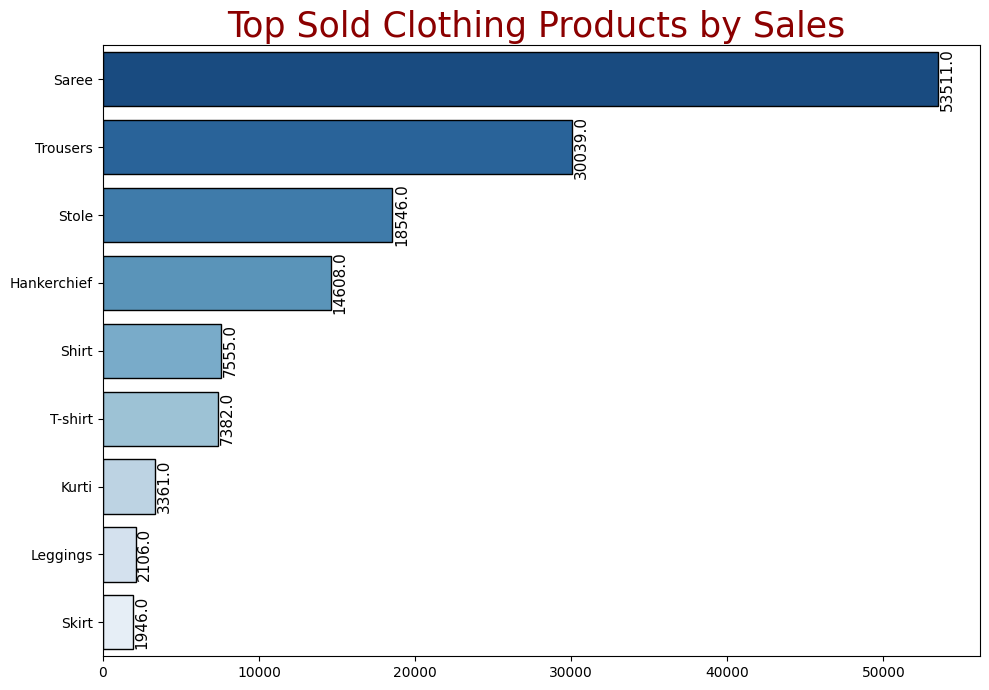

In [36]:
plt.figure(figsize=(10, 7))
sns.barplot(x=clothing_sales_top10.values, y=clothing_sales_top10.index, palette='Blues_r', edgecolor = 'black')
plt.title('Top Sold Clothing Products by Sales ', fontsize=25, color = 'darkred')
plt.xlabel('', )
plt.ylabel('', )
for i, value in enumerate(clothing_sales_top10.values):
    plt.text(value +100 , i, f'{value}', va='center', fontsize=11, rotation = 90)
plt.tight_layout()
plt.show()

In [37]:
#  Top  Sold Products by Total Sales in Electronics 
electronics_sales_top = (
    df2[df2['Category'] == 'Electronics']
    .groupby('Sub-Category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
electronics_sales_top

Sub-Category
Printers            58252.0
Phones              46119.0
Electronic Games    39168.0
Accessories         21728.0
Name: Amount, dtype: float64

C:\Users\Gaurav\AppData\Local\Temp\ipykernel_23056\1161901912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=electronics_sales_top.values, y=electronics_sales_top.index, palette='Oranges_r', edgecolor = 'black')


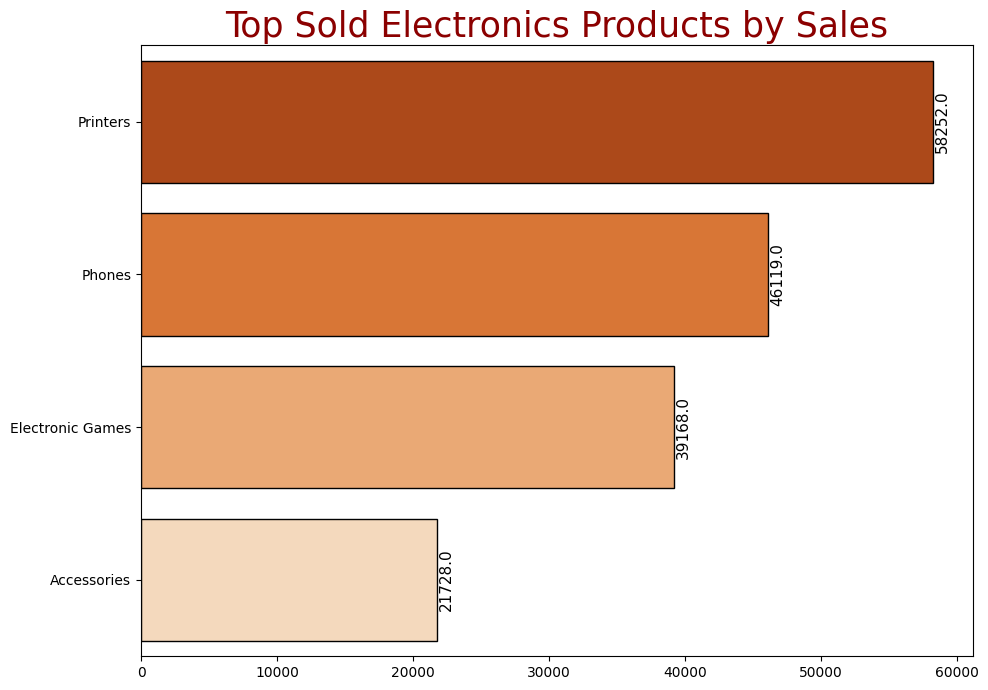

In [39]:
plt.figure(figsize=(10, 7))
sns.barplot(x=electronics_sales_top.values, y=electronics_sales_top.index, palette='Oranges_r', edgecolor = 'black')
plt.title('Top Sold Electronics Products by Sales', fontsize=25, color = 'darkred')
plt.xlabel('')
plt.ylabel('' )
for i, value in enumerate(electronics_sales_top.values):
    plt.text(value + 150, i, f'{value}', va='center', fontsize=11, rotation = 90)
plt.tight_layout()
plt.show()


In [40]:
# Top   Furniture Products
furniture_sales_top = (
    df2[df2['Category'] == 'Furniture']
    .groupby('Sub-Category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

furniture_sales_top

Sub-Category
Bookcases      56861.0
Chairs         34222.0
Tables         22614.0
Furnishings    13484.0
Name: Amount, dtype: float64

C:\Users\Gaurav\AppData\Local\Temp\ipykernel_23056\3946235398.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=furniture_sales_top.values, y=furniture_sales_top.index, palette='Greens_r', edgecolor = 'red')


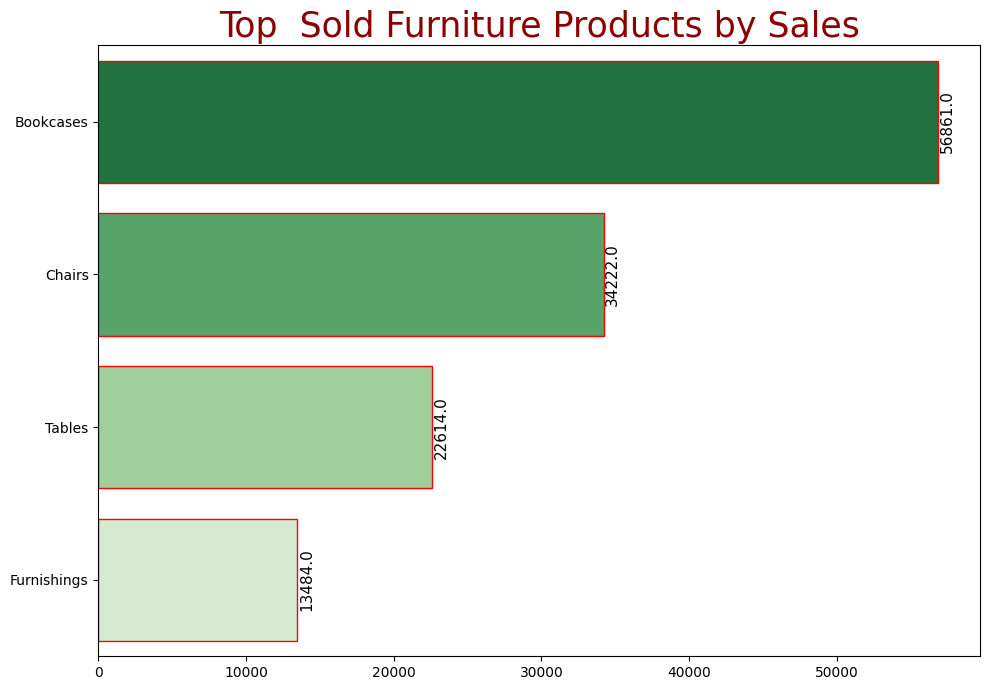

In [41]:
plt.figure(figsize=(10, 7))
sns.barplot(x=furniture_sales_top.values, y=furniture_sales_top.index, palette='Greens_r', edgecolor = 'red')
plt.title('Top  Sold Furniture Products by Sales', fontsize=25, color = 'darkred')
plt.xlabel('' )
plt.ylabel('')
for i, value in enumerate(furniture_sales_top.values):
    plt.text(value+100 , i, f'{value}', va='center', fontsize=11, rotation = 90)
plt.tight_layout()
plt.show()


## Sarees ,Trousers is the best seller in Clothing
## Printers , Phones is the best sellers in Electronics
## Bookcases, Chairs Is the best Seller in Furnitures

In [42]:
df_melted = pd.melt(sorted_metrics, id_vars='Category', value_vars=['Total_Profit', 'Total_Sales'],
                    var_name='Metric', value_name='Value')

C:\Users\Gaurav\AppData\Local\Temp\ipykernel_23056\2400065340.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df_melted, x='Category', y='Value', hue='Metric', palette='Set2', ci=None, edgecolor = 'brown')


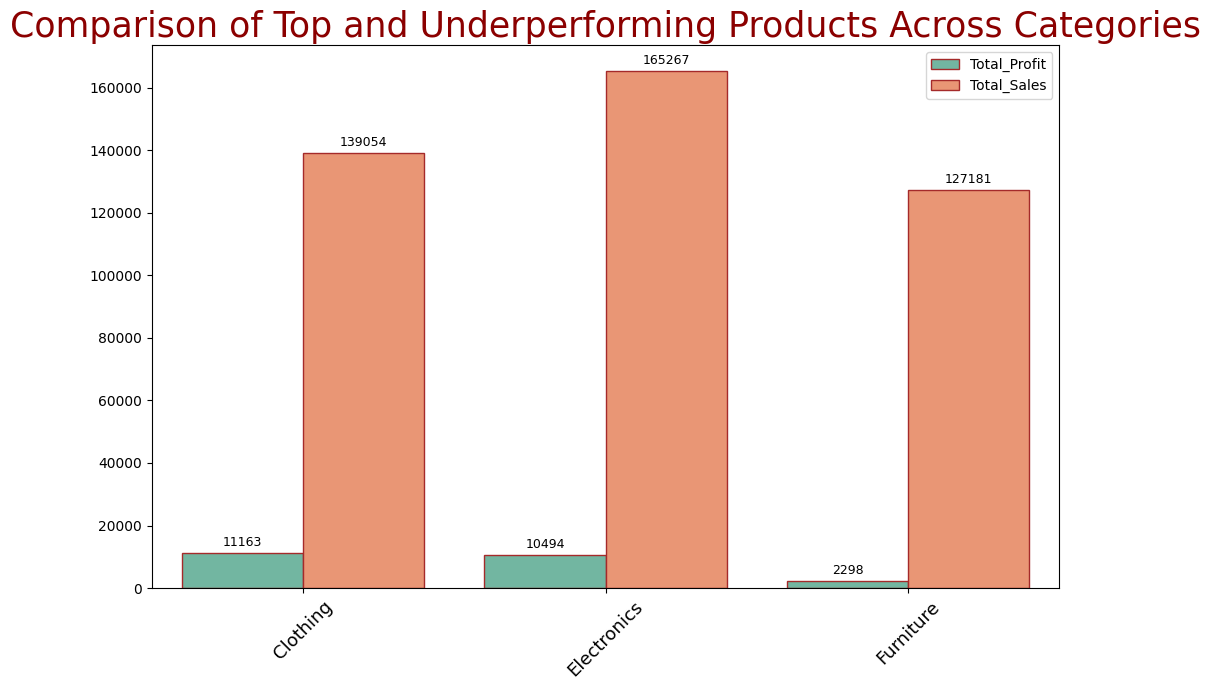

In [43]:
plt.figure(figsize=(10, 7))
ax = sns.barplot(data=df_melted, x='Category', y='Value', hue='Metric', palette='Set2', ci=None, edgecolor = 'brown')


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.0f}', 
                xy=(p.get_x() + p.get_width() / 2, height), 
                xytext=(0, 3), 
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, rotation=0)
plt.title("Comparison of Top and Underperforming Products Across Categories", fontsize = 25 , color= 'darkred')
plt.xlabel("", )
plt.ylabel("", )
plt.legend(title="")
plt.xticks(rotation=45, fontsize = 13)
plt.tight_layout()
plt.show()


## ------------------------------------------
# Observations
## --------------------------------------------

## 1. Clothing witnesses Largest Profits with even less Avg Profit which indicates consistent sales driving the whole Profits
## 2. Furniture experiences lowest Profits and Sales
## 3. Electronic products have highest Sales with a Significant amount of profits as per clothings

## ----------------------------------------------
# Suggestions
## -----------------------------------------------
## 1. Giving More Discounts and Offers on Best Selled Clothing Products Such as Sarees, Trousers to maintain consistency of customers & even increase them
## 2. To find more ways to make this Furnitures  cheaper, like cutting costs on making or Transportation.
## 3. Doing Surveys to collect information of Public for Furnitures like what kind do they most like; offering Customizations as per Customer Needs which will enhance Overall public Experience.
## 4. Optimizing logistics Services for Electonics to maintain high sales and Profits


# Part 2 Target Achievement Analysis

In [44]:
df3 = pd.read_csv('Sales_target.csv')
df3.head()

,Month of Order Date,Category,Target
0,Apr-18,Furniture,10400.0
1,May-18,Furniture,10500.0
2,Jun-18,Furniture,10600.0
3,Jul-18,Furniture,10800.0
4,Aug-18,Furniture,10900.0


In [45]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Month of Order Date  36 non-null     object 
 1   Category             36 non-null     object 
 2   Target               36 non-null     float64
dtypes: float64(1), object(2)
memory usage: 992.0+ bytes


In [46]:
df3.isnull().sum()

Month of Order Date    0
Category               0
Target                 0
dtype: int64

In [47]:
df3['Month of Order Date'] = pd.to_datetime(df3['Month of Order Date'], format='%b-%y', errors='coerce')

In [48]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Month of Order Date  36 non-null     datetime64[ns]
 1   Category             36 non-null     object        
 2   Target               36 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 992.0+ bytes


In [49]:
df3['MOM_Change'] = round(df3['Target'].pct_change() * 100, 2)
df3.head()

,Month of Order Date,Category,Target,MOM_Change
0,2018-04-01,Furniture,10400.0,NaN
1,2018-05-01,Furniture,10500.0,0.96
2,2018-06-01,Furniture,10600.0,0.95
3,2018-07-01,Furniture,10800.0,1.89
4,2018-08-01,Furniture,10900.0,0.93


In [50]:
df3['Month of Order Date'].unique()

<DatetimeArray>
['2018-04-01 00:00:00', '2018-05-01 00:00:00', '2018-06-01 00:00:00',
 '2018-07-01 00:00:00', '2018-08-01 00:00:00', '2018-09-01 00:00:00',
 '2018-10-01 00:00:00', '2018-11-01 00:00:00', '2018-12-01 00:00:00',
 '2019-01-01 00:00:00', '2019-02-01 00:00:00', '2019-03-01 00:00:00']
Length: 12, dtype: datetime64[ns]

In [51]:
df3['Month'] = df3['Month of Order Date'].dt.strftime('%B')
df3.head()

,Month of Order Date,Category,Target,MOM_Change,Month
0,2018-04-01,Furniture,10400.0,NaN,April
1,2018-05-01,Furniture,10500.0,0.96,May
2,2018-06-01,Furniture,10600.0,0.95,June
3,2018-07-01,Furniture,10800.0,1.89,July
4,2018-08-01,Furniture,10900.0,0.93,August


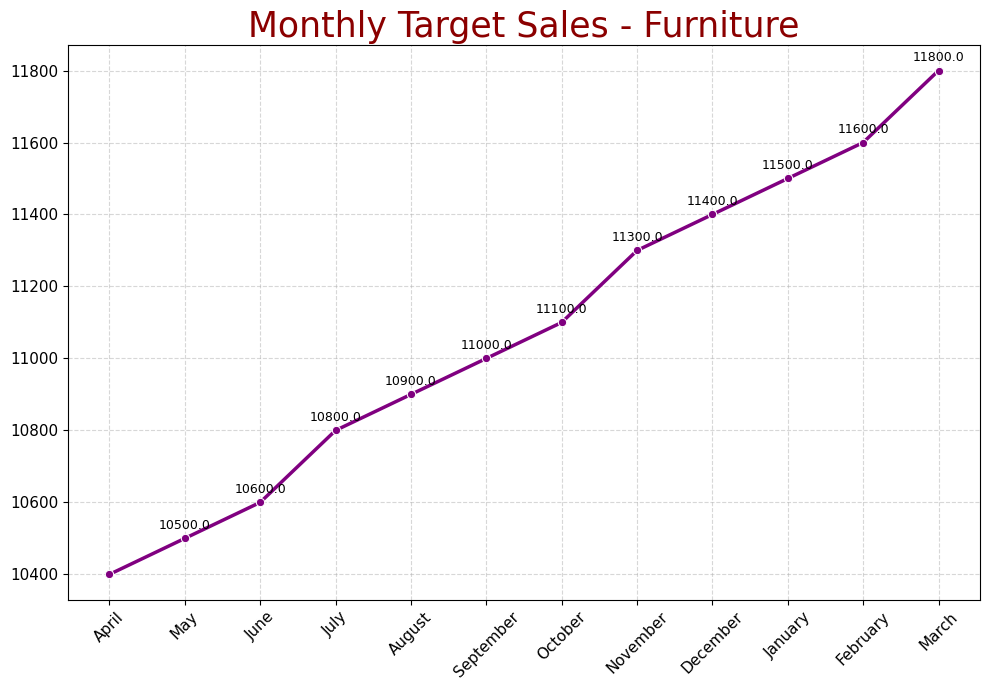

In [52]:
plt.figure(figsize=(10, 7))
ax = sns.lineplot(data=df3[df3['Category'] == 'Furniture'], x='Month', y='Target', marker='o', color='purple', linewidth=2.5)


for i, (x, y) in enumerate(zip(df3['Month'], df3['Target'])):
    if 0 < i < len(df3) - 1:
        ax.annotate(f'{y}', xy=(x, y), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=9, color='black')

plt.title('Monthly Target Sales - Furniture', fontsize=25, color='darkred')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [53]:
furniture_MOM_Sales = df3[df3['Category'] == 'Furniture']
furniture_MOM_Sales

,Month of Order Date,Category,Target,MOM_Change,Month
0,2018-04-01,Furniture,10400.0,NaN,April
1,2018-05-01,Furniture,10500.0,0.96,May
2,2018-06-01,Furniture,10600.0,0.95,June
3,2018-07-01,Furniture,10800.0,1.89,July
4,2018-08-01,Furniture,10900.0,0.93,August
5,2018-09-01,Furniture,11000.0,0.92,September
6,2018-10-01,Furniture,11100.0,0.91,October
7,2018-11-01,Furniture,11300.0,1.80,November
8,2018-12-01,Furniture,11400.0,0.88,December
9,2019-01-01,Furniture,11500.0,0.88,January


In [54]:
order_details_with_date = pd.merge(df2, df1, on='Order ID', how='left')

In [55]:
df_actual_sales = (
    order_details_with_date[order_details_with_date['Category'] == 'Furniture']
    .groupby(pd.Grouper(key='Order Date', freq='M'))['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Order Date': 'Month of Order Date', 'Amount': 'Actual_Sales'})
)
df_actual_sales.head()

C:\Users\Gaurav\AppData\Local\Temp\ipykernel_23056\198663825.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='Order Date', freq='M'))['Amount']


,Month of Order Date,Actual_Sales
0,2018-01-31,5056.0
1,2018-02-28,1141.0
2,2018-03-31,568.0
3,2018-04-30,1877.0
4,2018-05-31,1534.0


In [56]:
df_actual_sales['Month of Order Date'] = pd.to_datetime(df_actual_sales['Month of Order Date']).dt.to_period('M').dt.to_timestamp()



In [57]:
df_combined = pd.merge( df_actual_sales, df3, on='Month of Order Date', how='left')
df_combined['Achievement (%)'] = round((df_combined['Actual_Sales'] / df_combined['Target']) * 100, 2) 
df_combined.head()

,Month of Order Date,Actual_Sales,Category,Target,MOM_Change,Month,Achievement (%)
0,2018-01-01,5056.0,NaN,NaN,NaN,NaN,NaN
1,2018-02-01,1141.0,NaN,NaN,NaN,NaN,NaN
2,2018-03-01,568.0,NaN,NaN,NaN,NaN,NaN
3,2018-04-01,1877.0,Furniture,10400.0,NaN,April,18.05
4,2018-04-01,1877.0,Clothing,12000.0,1.69,April,15.64


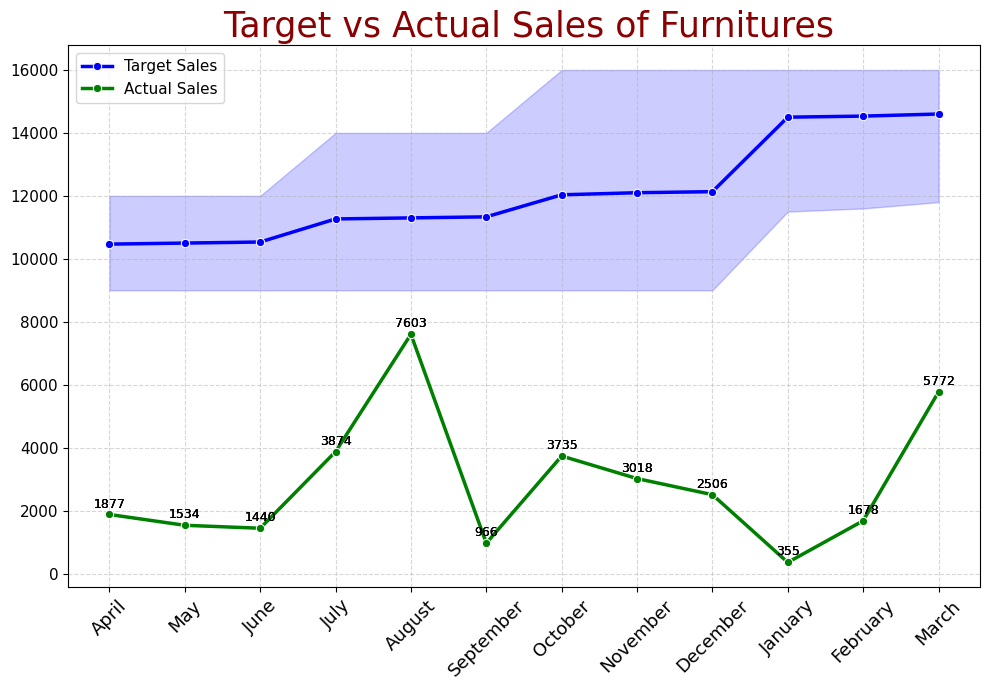

In [58]:
plt.figure(figsize=(10, 7))

#  Target and Actual Sales
sns.lineplot(data=df_combined, x='Month', y='Target', marker='o', label='Target Sales', color='blue', linewidth=2.5)
sns.lineplot(data=df_combined, x='Month', y='Actual_Sales', marker='o', label='Actual Sales', color='green', linewidth=2.5)



for x, y in zip(df_combined['Month'], df_combined['Actual_Sales']):
    plt.annotate(f'{int(y)}', xy=(x, y), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9)


plt.title(' Target vs Actual Sales of Furnitures', fontsize=25, color='darkred')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, fontsize=13)
plt.yticks(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


## ------------------------------------------------------------------
# Sugestions to decrease the Gaps Between Actual Sales and Target Sales
## ------------------------------------------------------------------
## 1. Priortizing  best Seller Products during our busiest months can help in decreasing these Huge Gaps Between Actual Sales and target Sales

## 2. Ensuring inventory remains aligned as  per Predicted Sales

## 3. Giving offers and Discounts to loyal Customers who purchase regularly and who purchase Expensice Products

## 4. Offering Customized features( eg;- Differnt types of Designs, Upgrades Available as per Customers too) in Furnitures for Public to attract them and Increasing Profits 


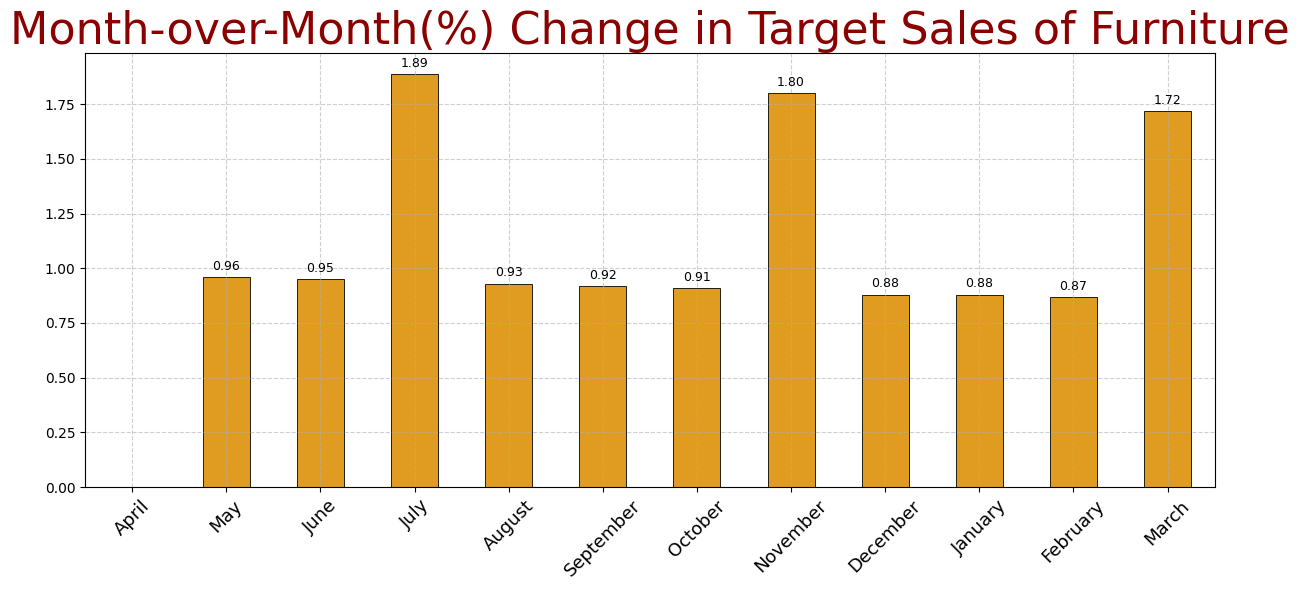

In [59]:
plt.figure(figsize=(12, 6))
a2 = sns.barplot(data=furniture_MOM_Sales, x='Month', y='MOM_Change', color='orange', width=0.5, edgecolor='black', linewidth=0.6)


for p in a2.patches:
    height = p.get_height()
    if not pd.isna(height) and height != 0: 
        a2.annotate(f'{height:.2f}', 
                     xy=(p.get_x() + p.get_width() / 2, height), 
                     xytext=(0, 3), 
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)


plt.title('Month-over-Month(%) Change in Target Sales of Furniture', fontsize=32, color = 'darkred')
plt.xlabel('')
plt.ylabel('', )

plt.xticks(rotation=45, fontsize = 13)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## ------------------------------------
# Observations
## ------------------------------------

## 1. 3 times fluctuations seen in MOM change(%) chart over the months of July, November & March
## 2. In All months MOM change remained consistent approxmaitely except those 3

## ------------------------------------
# Insights
## ------------------------------------

## 1. The fluctuations are expected be due to Holidays, festivals(eg:- Diwali & others) in November which people tends to spend more than usual.
## 2. Different Companies purchases new furnitures at the end of yearly budgets in March.
## 3. Replacing  Furnitures before Rainy season and Festive seasons (eg;- Ganesh Chaturthi, etc) is the reason to be expected behind July fluctuations.



# Part 3 Regional Performance Insights

In [60]:
state_order_counts = M3.groupby('State').agg(
    Order_Count=('Order ID', 'count'),
    Total_Sales=('Amount', 'sum'),
    Average_Profit=('Profit', 'mean')
).sort_values(by='Order_Count', ascending=False).head(5)

In [61]:
state_order_counts

,Order_Count,Total_Sales,Average_Profit
State,,,
Madhya Pradesh,340,105140.0,16.326471
Maharashtra,290,95348.0,21.296552
Gujarat,87,21058.0,5.344828
Delhi,74,22531.0,40.364865
Rajasthan,74,21149.0,16.986486


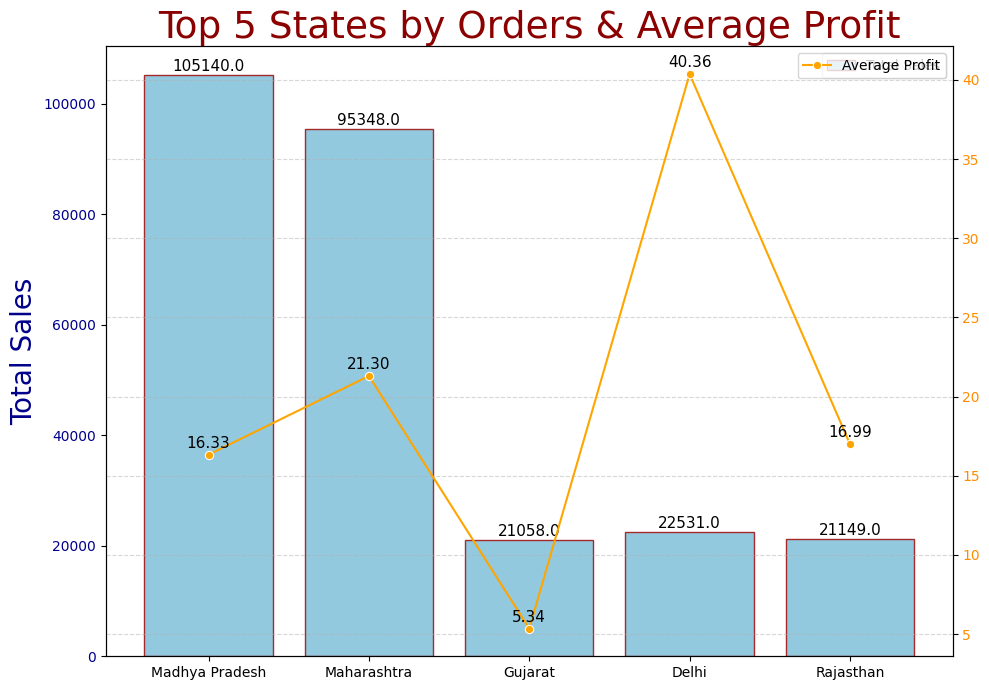

In [62]:
fig, ax = plt.subplots(figsize=(10, 7))

# Plot Total Sales
sns.barplot(x=state_order_counts.index, y=state_order_counts['Total_Sales'], color='skyblue', label='Total Sales', ax=ax, edgecolor = 'brown')

# Add sales values above bars
for i, value in enumerate(state_order_counts['Total_Sales']):
    ax.annotate(f'{value}', xy=(i, value), xytext=(0, 3), textcoords="offset points", ha='center', fontsize=11)


ax2 = ax.twinx()
sns.lineplot(x=state_order_counts.index, y=state_order_counts['Average_Profit'], marker='o', color='orange', label='Average Profit', ax=ax2)

# Add profit values above markers
for i, value in enumerate(state_order_counts['Average_Profit']):
    ax2.annotate(f'{value:.2f}', xy=(i, value), xytext=(0, 5), textcoords="offset points", ha='center', fontsize=11)



    


ax.set_title('Top 5 States by Orders & Average Profit', fontsize=27, color = 'darkred')
ax.set_xlabel('')
ax.set_ylabel('Total Sales', fontsize=20, color='darkblue')
ax2.set_ylabel('', )
ax.tick_params(axis='y', labelcolor='darkblue')
ax2.tick_params(axis='y', labelcolor='darkorange')
plt.xticks(rotation=90, fontsize =13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## ----------------------------------------------------
# Observations 
## ----------------------------------------------------
## 1. Madhya Pradesh is at the highest of Cities in terms of Maximum Customer Orders & even in Total Sales[ approx 40 % in Top 5 States ]
## 2. Delhi 4th by Orders have the highest Avg Profit which tells that they are selling Good Quality Products at a reasonable Price
## 3. Gujarat having the least Total Sales indicates Pricing Issues or maybe High Operational Costs.



## -----------------------------------------------------
# Suggestions
## -----------------------------------------------------
## 1. Increasing more Advertising and Promotions, in the states where we're not doing well(eg: - Gujarat, Rajasthan)
## 2. Improving the logistics could further Increase Profits States like MP & Maharashtra
## 3. Bringing more Quality Products to Delhi for customers to increase their spending.